**Dataset:** the setup cell selects the completed 262-fact five-shot ensemble when available. Set `DATASET = 'factorial'` to use the original 96-prompt discovery set. The descriptions of the original captures below refer to that factorial dataset.

Five-shot data use the same 262 fact/addend pairs at k=0 and k=20, with native correctness from their saved capture passes. Every target filler token and the separate `Answer`, `:`, assistant marker, and end-of-thinking marker are included; this prompt format has no trailing space. The five demonstrations also change filler length. Cohorts and prompt formats are kept separate.


# One-fact addition: top-object Logit Lens

Each panel is prompt position × decoder layer. Columns test the fact (`A`), addend (`X`), and sum (`A+X`). The default row asks whether that object is the top token among canonical nonnegative-integer tokens. Set `SHOW_TOP_TOKEN = True` in the setup cell to also show the full-vocabulary top-token row (or pass `show_top_token=True` to `show_heatmap`). Color is the fraction of examples (shared scale 0–1).

Compare **k = 20** and **k = 0** below, each split into all/correct/wrong examples. All three answer-prefix tokens are shown separately: `Answer`, `:`, and the trailing space. `answer_prompt` names the space, which predicts the first answer token. `last_question` is the historical label for `</think>`, immediately before the filler/answer prefix in these prompts.

The expanded data reuse complete k = 20 residuals from the patching experiment and new k = 0 residuals from job 58169491. Every position within a length uses correctness labels from the forward passes that produced its residuals. The original data remain available for k = 5 and 10; those original captures omit the separate `Answer` and `:` positions.

All expanded panels use SGLang’s native CUDA readout kernels. The earlier k = 20 figures used truncated-prompt captures and a Torch reference readout; these figures use the later full-prompt captures, so some existing cells also change. Original figures and data remain in `runs/deepseek-v4-flash/logit-lens/57804608/top-object-heatmap/`.


In [2]:
from pathlib import Path
import importlib
import json
import sys
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np

# Match addition_accuracy's mech-int (sglang) kernel, including when rerunning
# in an already-open NERSC Python kernel that did not inherit the TeX Live path.
TEXLIVE_BIN = Path('/global/common/software/nersc9/texlive/2024/bin/x86_64-linux')
# Use one complete TeX installation, including Matplotlib's font lookup tools.
if TEXLIVE_BIN.is_dir():
    tex_path = [entry for entry in os.environ.get('PATH', '').split(os.pathsep)
                if entry != str(TEXLIVE_BIN)]
    os.environ['PATH'] = os.pathsep.join([str(TEXLIVE_BIN), *tex_path])
missing_tex = [name for name in ('latex', 'dvipng', 'kpsewhich')
               if shutil.which(name) is None]
if missing_tex:
    raise RuntimeError(f"Missing LaTeX tools: {missing_tex}. Select the mech-int (sglang) "
                       "kernel, or load texlive/2024 before starting Jupyter.")
# Resolve fonts through this TeX installation directly. Matplotlib's persistent
# LuaTeX helper can inherit a different TeX search configuration from the kernel.
from functools import lru_cache
from unittest.mock import patch
import io
import subprocess
import matplotlib.dviread as dviread
from IPython.display import Image, display

KPSEWHICH = str(TEXLIVE_BIN / 'kpsewhich') if TEXLIVE_BIN.is_dir() else shutil.which('kpsewhich')

@lru_cache(maxsize=256)
def notebook_tex_file(filename):
    filename = os.fsdecode(filename)
    # Keep kernel-specific TeX search overrides out of this font lookup.
    lookup_env = {key: value for key, value in os.environ.items()
                  if not key.startswith('TEX') and key not in
                  {'TFMFONTS', 'VFFONTS', 'T1FONTS', 'ENCFONTS', 'FONTCONFIG_FILE'}}
    result = subprocess.run([KPSEWHICH, filename], env=lookup_env,
                            capture_output=True, text=True, timeout=10)
    found = result.stdout.strip()
    if result.returncode != 0 or not found or not Path(found).is_file():
        raise FileNotFoundError(f'{KPSEWHICH} could not resolve {filename!r}: '
                                f'{result.stderr.strip()}')
    return found

cmr_font = notebook_tex_file('cmr10.tfm')
print(f"TeX lookup: direct kpsewhich; Computer Modern: {cmr_font}")
print(f"Python: {sys.executable}")

SHOW_TOP_TOKEN = False  # True restores the full-vocabulary top row above the numerical row.

ROOT = Path.cwd()
if not (ROOT / 'filler').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import filler.dsv4.top_object_heatmap as heatmap_tools
importlib.reload(heatmap_tools)  # pick up local edits in an already-running kernel
OBJECTS = heatmap_tools.OBJECTS
aggregate_rows = heatmap_tools.aggregate_rows
read_jsonl = heatmap_tools.read_jsonl

from filler.dsv4.five_shot_jlens_heatmap import load_completed as load_five_shot, heatmap_stats
FIVE_SHOT_COMPLETE = ROOT / 'runs/deepseek-v4-flash/five-shot-jlens-heatmap/COMPLETE.json'
DATASET = 'five_shot' if FIVE_SHOT_COMPLETE.is_file() else 'factorial'  # Choose 'five_shot' or 'factorial'.
FIVE_SHOT_RUN = None  # Optional explicit completed scoring runtime.
VALIDATED_EXPORT = False  # Used only by the allocation-owned notebook validation.
if DATASET not in {'five_shot', 'factorial'}:
    raise ValueError("DATASET must be 'five_shot' or 'factorial'")
DATASET_LABEL = 'five-shot, 262 facts' if DATASET == 'five_shot' else 'factorial discovery'
if DATASET == 'five_shot':
    RUN = FIVE_SHOT_RUN or Path(json.loads(FIVE_SHOT_COMPLETE.read_text())['runtime'])
    completion, logit_summary = load_five_shot(RUN, validated=VALIDATED_EXPORT, lens='logit')
    for k in (0, 20):
        for cohort in ('all', 'correct', 'wrong'):
            heatmap_stats(logit_summary, completion, k, cohort, lens='logit')
else:
    BASE_ROWS = ROOT / 'runs/deepseek-v4-flash/logit-lens/57804608/top-object-heatmap/lens_rows_with_numeric_argmax.jsonl'
    assert BASE_ROWS.is_file(), BASE_ROWS
    COMPLETE = ROOT / 'runs/deepseek-v4-flash/answer-token-heatmap/COMPLETE.json'
    expanded = json.loads(COMPLETE.read_text()) if COMPLETE.is_file() else None
    if expanded is not None:
        assert expanded['status'] == 'complete' and expanded['rows'] == 115584
        EXPANDED_ROWS = Path(expanded['rows_path'])
        assert EXPANDED_ROWS.is_file(), EXPANDED_ROWS
        print('Expanded capture: Answer, colon, and space are available for k = 0 and 20.')
    else:
        print('Showing original captures. Answer and colon require the pending GPU capture; only the trailing space is currently available.')

    def rows_for_length(k):
        if expanded is not None and k in expanded['filler_lengths']:
            return EXPANDED_ROWS
        return BASE_ROWS

print(f'Dataset: {DATASET_LABEL}')


TeX lookup: direct kpsewhich; Computer Modern: /global/common/software/nersc9/texlive/2024-17c650b50c05ee823c6093081103ed0ab76a21df/texmf-dist/fonts/tfm/public/cm/cmr10.tfm
Python: /global/common/software/nersc/pe/conda-envs/26.8.0/python-3.13/nersc-python/bin/python
Dataset: five-shot, 262 facts


In [3]:
def show_heatmap(filler_length=20, cohort='all', show_grid=True, show_top_token=False):
    if cohort not in {'all', 'correct', 'wrong'}:
        raise ValueError("cohort must be 'all', 'correct', or 'wrong'")
    correct = None if cohort == 'all' else cohort == 'correct'
    if DATASET == 'five_shot':
        stats = heatmap_stats(logit_summary, completion, filler_length, cohort, lens='logit')
    else:
        stats = aggregate_rows(read_jsonl(rows_for_length(filler_length)), filler_length=filler_length, correct=correct)
    positions, layers = stats['positions'], stats['layers']
    rows = [('numeric', 'Top numerical token')]
    if show_top_token:
        rows.insert(0, ('all', 'Top token'))
    row_count = len(rows)
    fig, axes = plt.subplots(
        row_count, 3, figsize=(16, row_count * max(4, 0.25 * len(positions))),
        sharex=True, sharey=True, squeeze=False, constrained_layout=True,
    )
    for i, (scope, row_title) in enumerate(rows):
        for j, (obj, title) in enumerate(zip(OBJECTS, ('Fact (A)', 'Addend (X)', 'Sum (A+X)'))):
            ax = axes[i, j]
            image = ax.imshow(np.asarray(stats['rates'][scope][obj]), origin='lower', aspect='auto',
                              interpolation='nearest', cmap='magma', vmin=0, vmax=1)
            if show_grid:
                # Place grid lines at cell boundaries.
                ax.set_xticks(np.arange(len(layers) + 1) - 0.5, minor=True)
                ax.set_yticks(np.arange(len(positions) + 1) - 0.5, minor=True)
                ax.grid(
                    which='minor', color='white', linestyle=':',
                    linewidth=0.6, alpha=0.8
                )
                ax.tick_params(which='minor', bottom=False, left=False)
            ax.set_title(title)
            if j == 0:
                ax.set_ylabel(f'{row_title}\nprompt position')
                ax.set_yticks(range(len(positions)), [heatmap_tools.position_tick_label(p).replace('_', r'\_')
                                                    if plt.rcParams['text.usetex'] else heatmap_tools.position_tick_label(p)
                                                    for p in positions])
            if i == row_count - 1:
                ax.set_xlabel('decoder layer')
                ticks = list(range(0, len(layers), max(1, len(layers) // 7)))
                ax.set_xticks(ticks, [layers[k] for k in ticks])
    counts = set(stats['example_counts'].values())
    assert len(counts) == 1, 'Inconsistent cohort coverage'
    count = counts.pop()
    missing = [p for p in ('answer_word', 'answer_colon') if p not in positions]
    suffix = ' — Answer/colon not yet captured' if missing else ''
    fig.suptitle(f'One-fact addition: {DATASET_LABEL} — {cohort} (N={count}, k={filler_length}){suffix}')
    fig.colorbar(image, ax=axes, label='fraction of examples', shrink=0.9)
    # Finish rendering while the direct font resolver is active. Display PNG
    # bytes so Jupyter does not defer a second TeX render until after this scope.
    try:
        png = io.BytesIO()
        with patch.object(dviread, 'find_tex_file', notebook_tex_file):
            fig.savefig(png, format='png', dpi=fig.dpi, bbox_inches='tight')
        display(Image(data=png.getvalue()))
    finally:
        plt.close(fig)
    return stats


## k = 20: twenty filler tokens


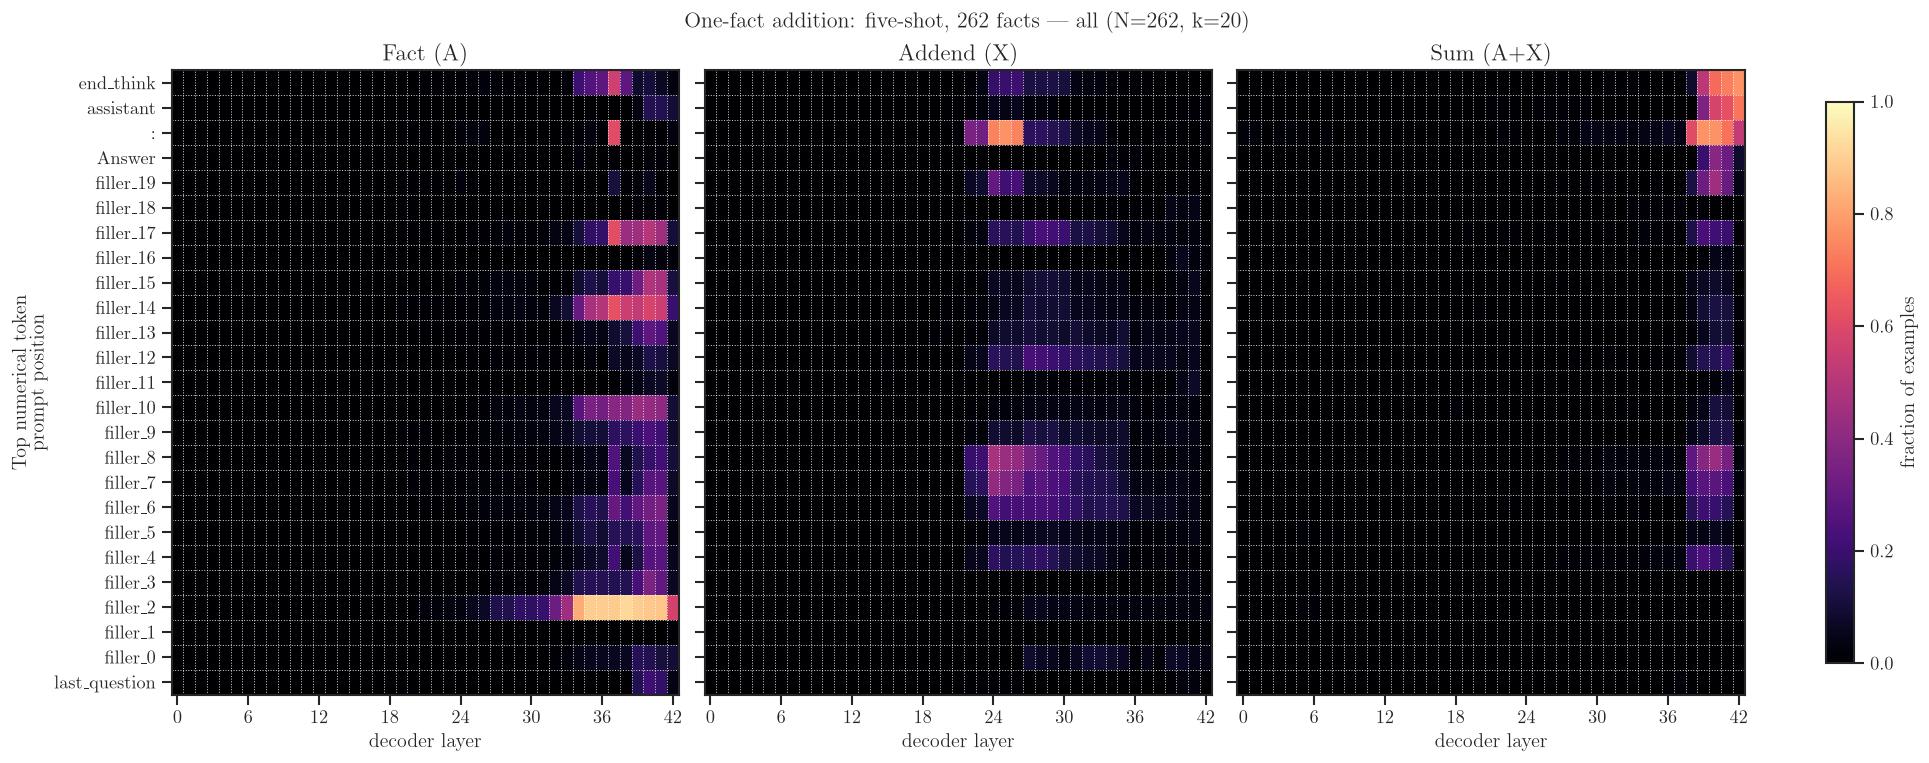

In [4]:
stats_all = show_heatmap(20, 'all', show_top_token=SHOW_TOP_TOKEN)


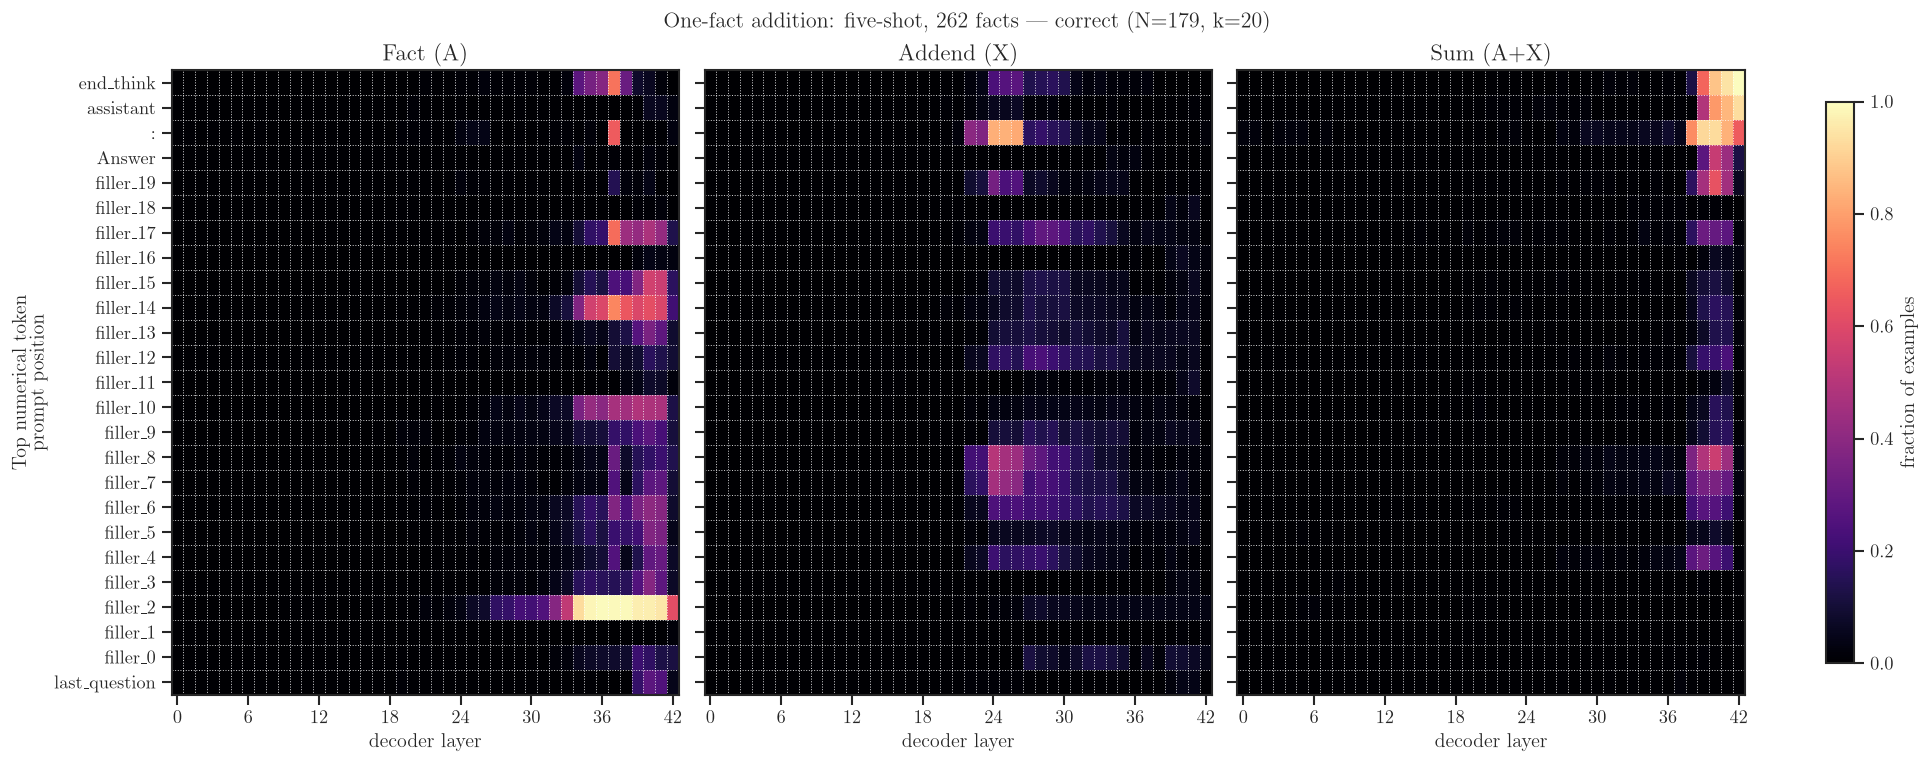

In [5]:
stats_correct = show_heatmap(20, 'correct', show_top_token=SHOW_TOP_TOKEN)


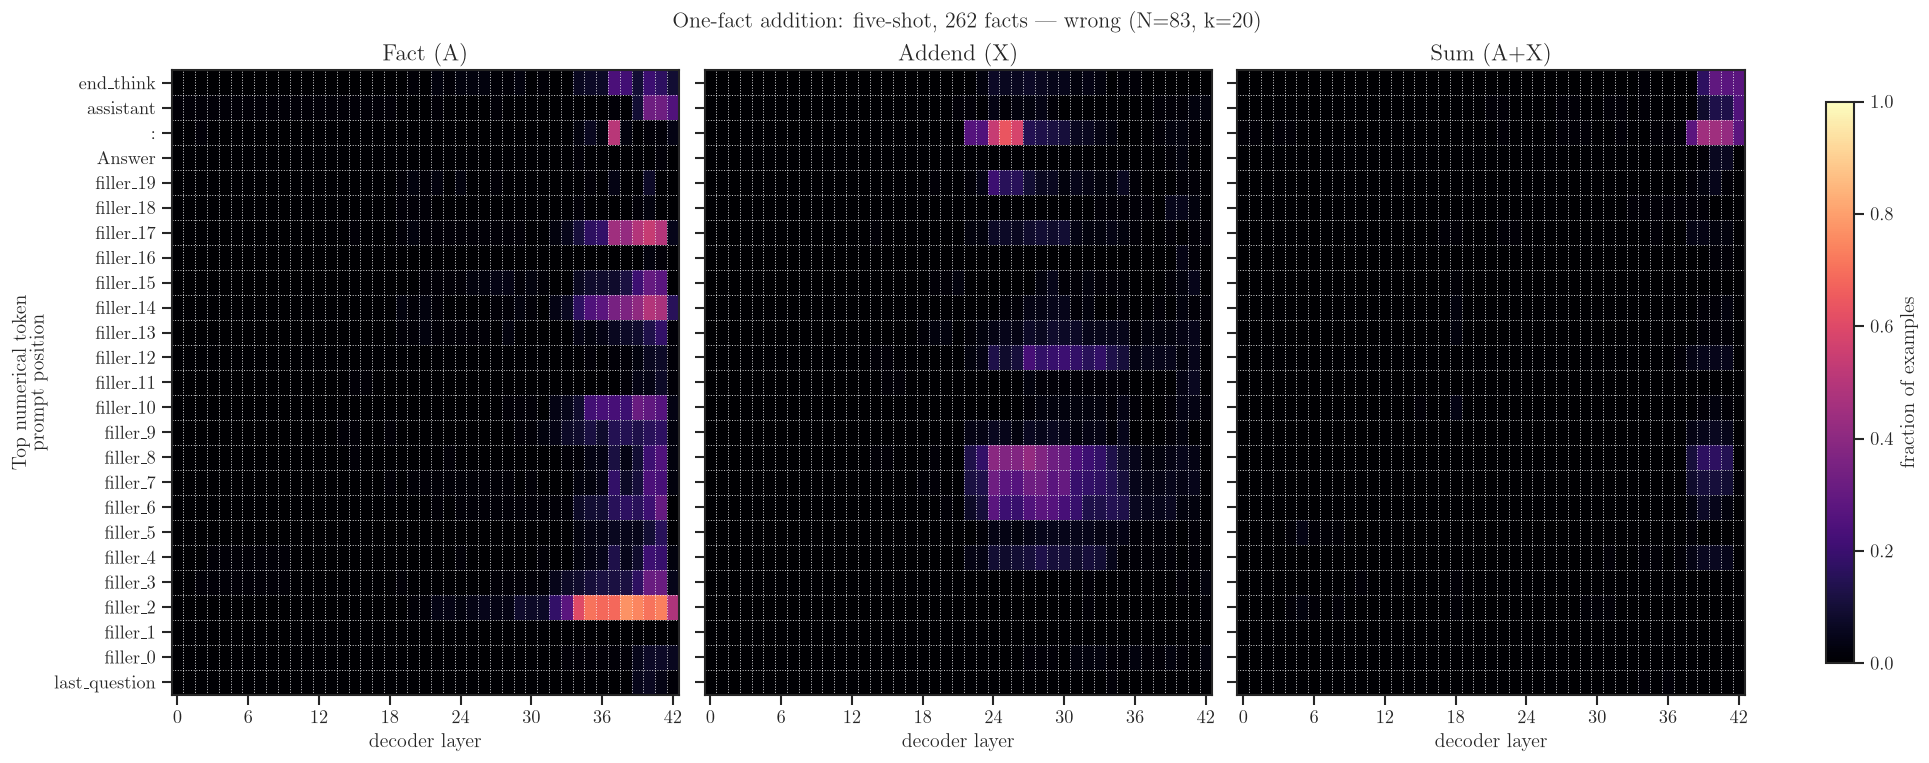

In [6]:
stats_wrong = show_heatmap(20, 'wrong', show_top_token=SHOW_TOP_TOKEN)


## k = 0: no filler


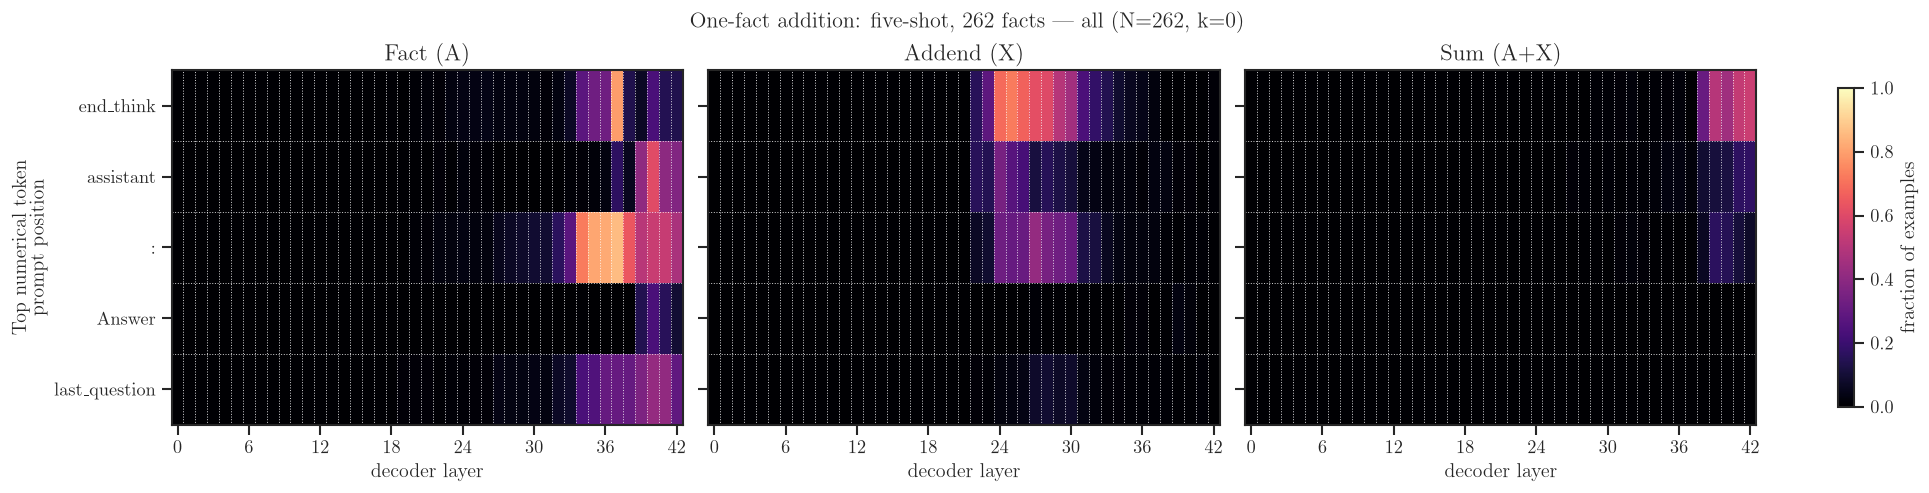

In [7]:
stats_k0_all = show_heatmap(0, 'all', show_top_token=SHOW_TOP_TOKEN)


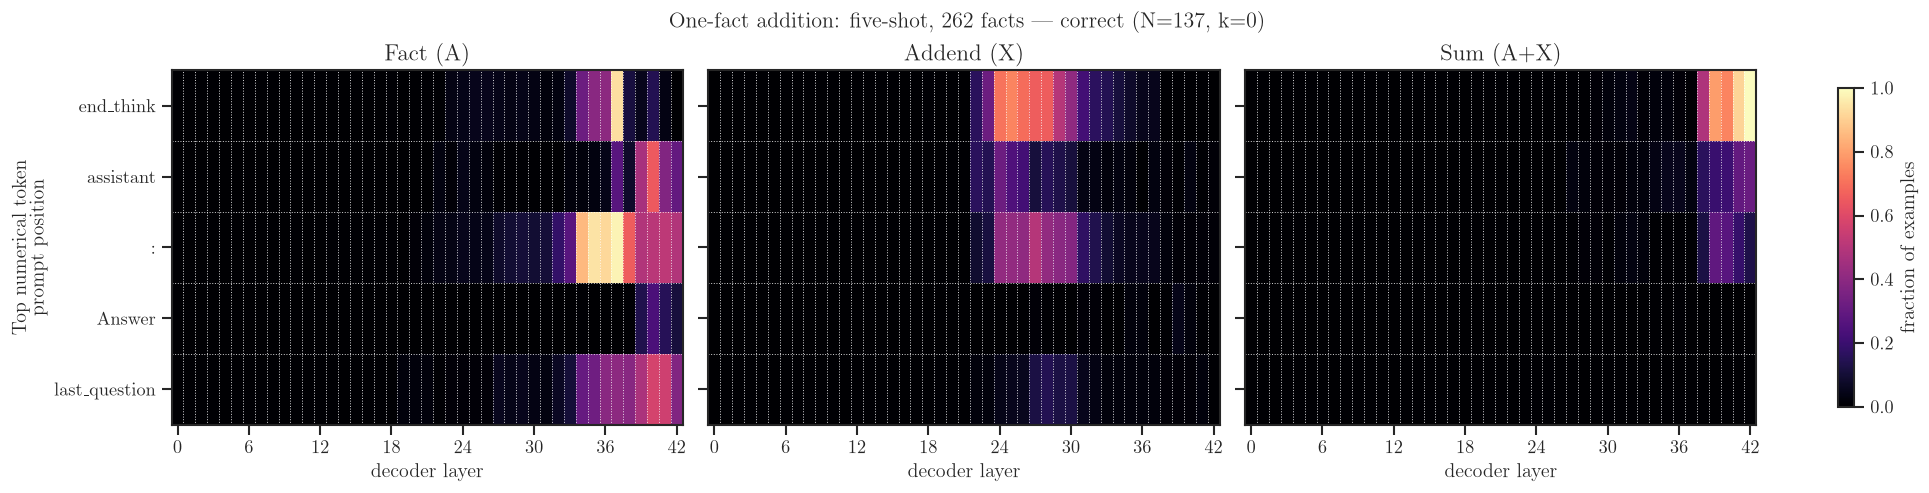

In [8]:
stats_k0_correct = show_heatmap(0, 'correct', show_top_token=SHOW_TOP_TOKEN)


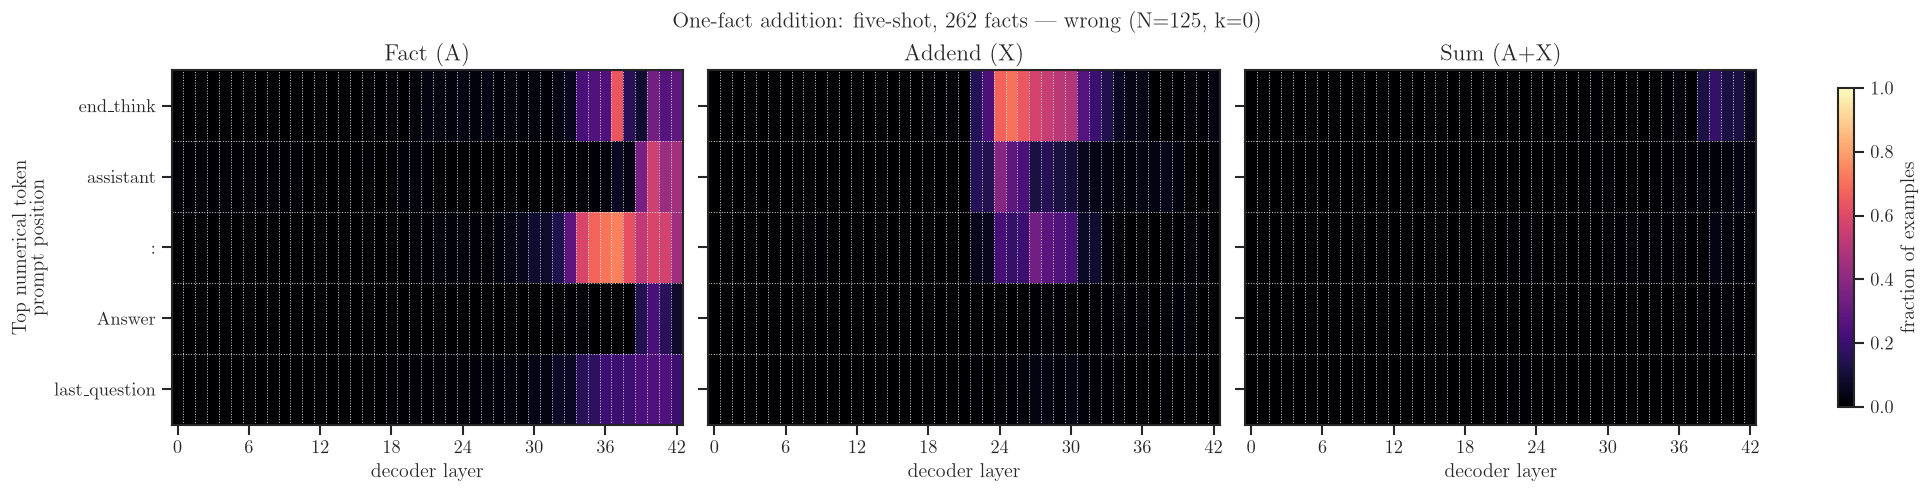

In [9]:
stats_k0_wrong = show_heatmap(0, 'wrong', show_top_token=SHOW_TOP_TOKEN)


In [10]:
# Original data also support k = 5 and 10.
available_filler_lengths = ([0, 20] if DATASET == 'five_shot' else
                            sorted({int(row['filler_length']) for row in read_jsonl(BASE_ROWS)}))
available_filler_lengths


[0, 20]

In [11]:
# Exact rates plotted in any panel, as a position × layer array.
sum_numeric_rates = np.asarray(stats_all['rates']['numeric']['A+X'])
sum_numeric_rates.shape, sum_numeric_rates.min(), sum_numeric_rates.max()


((25, 43), np.float64(0.0), np.float64(0.7748091603053435))